# **CIFAR100 Dataset PyTorch Benchmark (Machine Learning vs Deep Learning)**

In [ ]:
# Install PyTorch for CPU Version
!pip install torch torchvision torchaudio

In [ ]:
# CUDA Version
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
!pip -q install torch torchvision scikit-learn seaborn pandas matplotlib

In [1]:
import torch

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.11.0+cpu


In [1]:
# Import Library

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, matthews_corrcoef
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


In [2]:
# CIFAR100 Data Module
class CIFAR100DataModule:
    def __init__(self, batch_size=128):
        self.batch_size=batch_size
        tfm=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])
        self.train_ds=datasets.CIFAR100("./data",train=True,download=True,transform=tfm)
        self.test_ds=datasets.CIFAR100("./data",train=False,download=True,transform=tfm)

    # training data
    def train_loader(self):
        return DataLoader(self.train_ds,batch_size=self.batch_size,shuffle=True)

    # testing data
    def test_loader(self):
        return DataLoader(self.test_ds,batch_size=self.batch_size,shuffle=False)

# load data
dm=CIFAR100DataModule()


100%|██████████| 169M/169M [00:05<00:00, 31.0MB/s]


In [3]:
# create simple CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self,num_classes=100):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8,512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        return self.classifier(self.features(x))


In [5]:
# Training Class (fit, epoch)

class Trainer:
    def __init__(self,model):
        self.model=model.to(DEVICE)

    def fit(self,loader,epochs=5):
        criterion=nn.CrossEntropyLoss()
        optimizer=optim.Adam(self.model.parameters(),lr=1e-3)

        for epoch in range(epochs):
            self.model.train()
            loss_sum=0
            for x,y in loader:
                x,y=x.to(DEVICE),y.to(DEVICE)
                optimizer.zero_grad()
                out=self.model(x)
                loss=criterion(out,y)
                loss.backward()
                optimizer.step()
                loss_sum+=loss.item()
            print(f"Epoch {epoch+1}: {loss_sum/len(loader):.4f}")


In [6]:
# Model Evaluation (using confusion matrix TP, TN, FP, FN)
class Evaluator:
    @staticmethod
    def evaluate_torch(model,loader):
        model.eval()
        y_true=[]
        y_pred=[]
        probs=[]

        with torch.no_grad():
            for x,y in loader:
                x=x.to(DEVICE)
                out=model(x)
                p=torch.softmax(out,dim=1)

                y_true.extend(y.numpy())
                y_pred.extend(out.argmax(1).cpu().numpy())
                probs.extend(p.cpu().numpy())

        return np.array(y_true),np.array(y_pred),np.array(probs)

    @staticmethod
    def metrics(y_true,y_pred):
        acc=accuracy_score(y_true,y_pred)
        mcc=matthews_corrcoef(y_true,y_pred)

        cm=confusion_matrix(y_true,y_pred)

        sensitivity=np.mean(np.diag(cm)/(cm.sum(axis=1)+1e-9))

        specificity_list=[]
        for i in range(cm.shape[0]):
            TP=cm[i,i]
            FN=cm[i,:].sum()-TP
            FP=cm[:,i].sum()-TP
            TN=cm.sum()-TP-FN-FP
            specificity_list.append(TN/(TN+FP+1e-9))

        specificity=np.mean(specificity_list)

        return acc,sensitivity,specificity,mcc


In [7]:
# Train CNN
cnn=SimpleCNN()
trainer=Trainer(cnn)
trainer.fit(dm.train_loader(),epochs=5)

# separate data
y_true,y_pred,y_prob=Evaluator.evaluate_torch(cnn,dm.test_loader())

# evaluate the output
cnn_metrics=Evaluator.metrics(y_true,y_pred)

# print metrics
print(cnn_metrics)

# save model
torch.save(cnn.state_dict(),"cnn.pt")

Epoch 1: 3.4885
Epoch 2: 2.6948
Epoch 3: 2.3013
Epoch 4: 1.9850
Epoch 5: 1.6989
(0.4057, np.float64(0.40569999999594303), np.float64(0.9939969696968692), np.float64(0.40015764250744384))


In [8]:
# Train ResNet18
resnet=models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc=nn.Linear(resnet.fc.in_features,100)

# training the model
trainer=Trainer(resnet)
trainer.fit(dm.train_loader(),epochs=3)

# separate data
y_true_r,y_pred_r,y_prob_r=Evaluator.evaluate_torch(resnet,dm.test_loader())

# evaluate the model
resnet_metrics=Evaluator.metrics(y_true_r,y_pred_r)

# save model
torch.save(resnet.state_dict(),"resnet18.pt")
print(resnet_metrics)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


Epoch 1: 2.6784
Epoch 2: 1.9157
Epoch 3: 1.5693
(0.4943, np.float64(0.494299999995057), np.float64(0.9948919191918186), np.float64(0.4896242454938184))


In [10]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, matthews_corrcoef
from torchvision import datasets

# Random Forest Baseline

# Load CIFAR100 dataset without any transforms initially
rf_train_ds = datasets.CIFAR100("./data", train=True, download=True)
rf_test_ds = datasets.CIFAR100("./data", train=False, download=True)

# Access data directly from the dataset's .data attribute (which is already a numpy array)
# and flatten the image data for the Random Forest Classifier
X_train = rf_train_ds.data[:5000].reshape(5000, -1)
y_train = np.array(rf_train_ds.targets[:5000])

X_test = rf_test_ds.data.reshape(len(rf_test_ds), -1)
y_test = np.array(rf_test_ds.targets)

# Initialize and train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

# Make predictions on the test set
rf_pred = rf.predict(X_test)

# Evaluate the model using the custom metrics function
rf_metrics = Evaluator.metrics(y_test, rf_pred)
print(rf_metrics)

(0.1493, np.float64(0.149299999998507), np.float64(0.9914070707069703), np.float64(0.14107046317844218))


**The Random Forest baseline model.**
The metrics are:
Accuracy: 0.1493
Sensitivity: 0.1493
Specificity: 0.9914
Matthews Correlation Coefficient (MCC): 0.1411

# **Confusion Matrix**

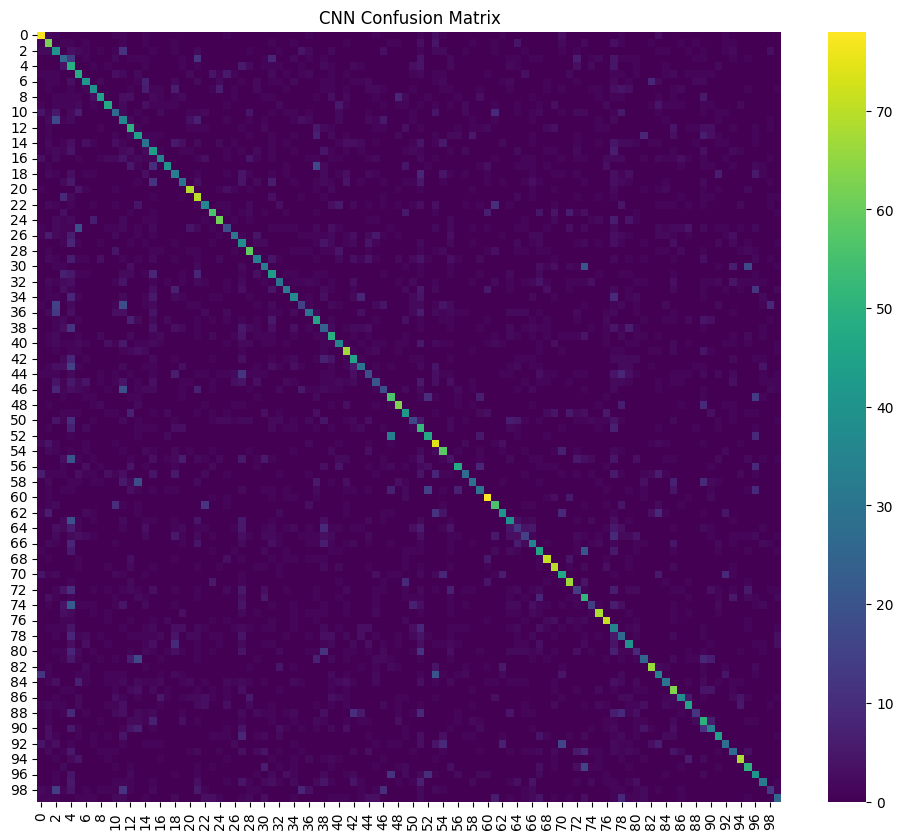

In [11]:
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm,cmap="viridis")
plt.title("CNN Confusion Matrix")
plt.show()

# **ROC Curve (Micro Average)**

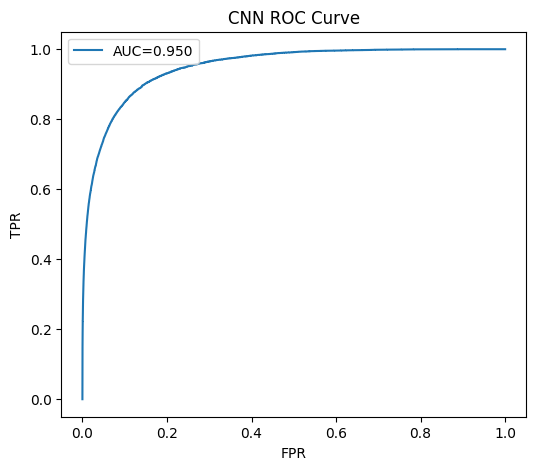

In [12]:
y_bin=label_binarize(y_true,classes=np.arange(100))

fpr,tpr,_=roc_curve(y_bin.ravel(),y_prob.ravel())
roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("CNN ROC Curve")
plt.show()

# **Model Comparison Table**

In [13]:
df=pd.DataFrame({
    "Model":["Random Forest","CNN","ResNet18"],
    "Accuracy":[rf_metrics[0],cnn_metrics[0],resnet_metrics[0]],
    "Sensitivity":[rf_metrics[1],cnn_metrics[1],resnet_metrics[1]],
    "Specificity":[rf_metrics[2],cnn_metrics[2],resnet_metrics[2]],
    "MCC":[rf_metrics[3],cnn_metrics[3],resnet_metrics[3]]
})
df.sort_values("Accuracy",ascending=False)

,Model,Accuracy,Sensitivity,Specificity,MCC
2,ResNet18,0.4943,0.4943,0.994892,0.489624
1,CNN,0.4057,0.4057,0.993997,0.400158
0,Random Forest,0.1493,0.1493,0.991407,0.141070
